## Problem 7: Forecasting Monthly Stock-Market Direction 

**Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

**Load Fama-French 3-Factor data**

In [2]:
ff3_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip"

ff3_raw = pd.read_csv(
    ff3_url,
    compression="zip",
    skiprows=3
)

ff3_raw.head()

,Unnamed: 0,Mkt-RF,SMB,HML,RF
0,192607,2.89,-2.55,-2.39,0.22
1,192608,2.64,-1.14,3.81,0.25
2,192609,0.38,-1.36,0.05,0.23
3,192610,-3.27,-0.14,0.82,0.32
4,192611,2.54,-0.11,-0.61,0.31


**Cleaning Data**

In [3]:
ff3 = ff3_raw.copy()

ff3 = ff3.rename(columns={ff3.columns[0]: "Date"})

ff3 = ff3[ff3["Date"].astype(str).str.isnumeric()]
ff3 = ff3[ff3["Date"].astype(str).str.len() == 6]

ff3["Date"] = pd.to_datetime(ff3["Date"].astype(str), format="%Y%m")

ff3["Mkt-RF"] = pd.to_numeric(ff3["Mkt-RF"], errors="coerce")
ff3["SMB"] = pd.to_numeric(ff3["SMB"], errors="coerce")
ff3["HML"] = pd.to_numeric(ff3["HML"], errors="coerce")
ff3["RF"] = pd.to_numeric(ff3["RF"], errors="coerce")

ff3.head()

,Date,Mkt-RF,SMB,HML,RF
0,1926-07-01,2.89,-2.55,-2.39,0.22
1,1926-08-01,2.64,-1.14,3.81,0.25
2,1926-09-01,0.38,-1.36,0.05,0.23
3,1926-10-01,-3.27,-0.14,0.82,0.32
4,1926-11-01,2.54,-0.11,-0.61,0.31


**Load Yield Spread data from FRED**

In [4]:
spread_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=T10Y3MM"

spread = pd.read_csv(spread_url)

spread = spread.rename(columns={
    "observation_date": "Date",
    "T10Y3MM": "Yield_Spread"
})

spread["Date"] = pd.to_datetime(spread["Date"])

spread["Yield_Spread"] = pd.to_numeric(
    spread["Yield_Spread"],
    errors="coerce"
)

spread.head()

,Date,Yield_Spread
0,1982-01-01,1.67
1,1982-02-01,0.15
2,1982-03-01,0.55
3,1982-04-01,0.53
4,1982-05-01,0.91


**Load Recession indicator from FRED**

In [5]:
recession_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=USREC"

recession = pd.read_csv(recession_url)

recession = recession.rename(columns={
    "observation_date": "Date",
    "USREC": "Recession"
})

recession["Date"] = pd.to_datetime(recession["Date"])

recession["Recession"] = pd.to_numeric(
    recession["Recession"],
    errors="coerce"
)

recession.head()

,Date,Recession
0,1854-12-01,1
1,1855-01-01,0
2,1855-02-01,0
3,1855-03-01,0
4,1855-04-01,0


**Merge all datasets**

In [6]:
data = pd.merge(ff3, spread, on="Date", how="inner")

data = pd.merge(data, recession, on="Date", how="inner")

data.head()

,Date,Mkt-RF,SMB,HML,RF,Yield_Spread,Recession
0,1982-01-01,-3.23,-1.25,3.19,0.80,1.67,1
1,1982-02-01,-5.86,0.46,6.09,0.92,0.15,1
2,1982-03-01,-1.82,-0.19,3.76,0.98,0.55,1
3,1982-04-01,3.24,1.64,-3.08,1.13,0.53,1
4,1982-05-01,-3.93,0.17,1.78,1.06,0.91,1


**Create target variable**

In [7]:
data["Next_Month_Mkt_RF"] = data["Mkt-RF"].shift(-1)

data["Market_Up_Next_Month"] = np.where(
    data["Next_Month_Mkt_RF"] > 0,
    1,
    0
)

data[["Date", "Mkt-RF", "Next_Month_Mkt_RF", "Market_Up_Next_Month"]].head()

,Date,Mkt-RF,Next_Month_Mkt_RF,Market_Up_Next_Month
0,1982-01-01,-3.23,-5.86,0
1,1982-02-01,-5.86,-1.82,0
2,1982-03-01,-1.82,3.24,1
3,1982-04-01,3.24,-3.93,0
4,1982-05-01,-3.93,-3.08,0


**Create predictor variables**

In [8]:
data["Mkt_RF_Lag1"] = data["Mkt-RF"]
data["SMB_Lag1"] = data["SMB"]
data["HML_Lag1"] = data["HML"]
data["Yield_Spread_Lag1"] = data["Yield_Spread"]
data["Recession_Lag1"] = data["Recession"]

data["Rolling_12M_Volatility"] = data["Mkt-RF"].rolling(window=12).std()

data[
    [
        "Date",
        "Market_Up_Next_Month",
        "Mkt_RF_Lag1",
        "SMB_Lag1",
        "HML_Lag1",
        "Yield_Spread_Lag1",
        "Recession_Lag1",
        "Rolling_12M_Volatility"
    ]
].head(15)

,Date,Market_Up_Next_Month,Mkt_RF_Lag1,SMB_Lag1,HML_Lag1,Yield_Spread_Lag1,Recession_Lag1,Rolling_12M_Volatility
0,1982-01-01,0,-3.23,-1.25,3.19,1.67,1,NaN
1,1982-02-01,0,-5.86,0.46,6.09,0.15,1,NaN
2,1982-03-01,1,-1.82,-0.19,3.76,0.55,1,NaN
3,1982-04-01,0,3.24,1.64,-3.08,0.53,1,NaN
4,1982-05-01,0,-3.93,0.17,1.78,0.91,1,NaN
5,1982-06-01,0,-3.08,-0.43,1.56,1.22,1,NaN
6,1982-07-01,1,-3.20,0.91,0.07,2.09,1,NaN
7,1982-08-01,1,11.23,-4.28,1.09,4.06,1,NaN
8,1982-09-01,1,1.31,2.87,0.23,4.15,1,NaN
9,1982-10-01,1,11.30,2.38,-3.62,2.94,1,NaN


Do not worry about the first 11 rows having missing volatility values. That happens because rolling 12-month volatility needs 12 months of data.

In [9]:
model_data = data.dropna(
    subset=[
        "Market_Up_Next_Month",
        "Mkt_RF_Lag1",
        "SMB_Lag1",
        "HML_Lag1",
        "Yield_Spread_Lag1",
        "Recession_Lag1",
        "Rolling_12M_Volatility"
    ]
).copy()

model_data.shape

(522, 15)

In [10]:
model_data["Market_Up_Next_Month"].value_counts()

Market_Up_Next_Month
1    328
0    194
Name: count, dtype: int64

**Plot: Market Excess return over Time**

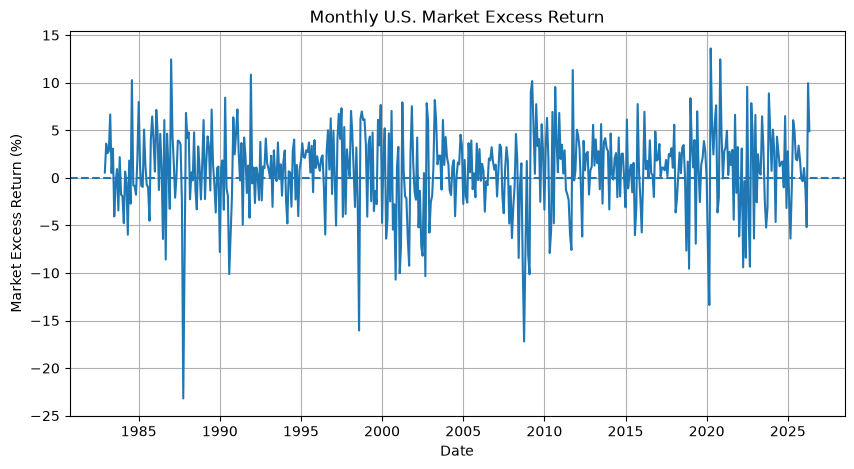

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(model_data["Date"], model_data["Mkt-RF"])

plt.axhline(0, linestyle="--")

plt.xlabel("Date")
plt.ylabel("Market Excess Return (%)")
plt.title("Monthly U.S. Market Excess Return")
plt.grid(True)

plt.show()

In [12]:
train = model_data[model_data["Date"] < "2005-01-01"].copy()
test = model_data[model_data["Date"] >= "2005-01-01"].copy()

train.shape, test.shape

((265, 15), (257, 15))

**Define X and y**

In [13]:
features = [
    "Mkt_RF_Lag1",
    "SMB_Lag1",
    "HML_Lag1",
    "Yield_Spread_Lag1",
    "Recession_Lag1",
    "Rolling_12M_Volatility"
]

X_train = train[features]
y_train = train["Market_Up_Next_Month"]

X_test = test[features]
y_test = test["Market_Up_Next_Month"]

**Fit Logistic Regression model**

In [14]:
logit_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=5000))
])

logit_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Mkt_RF_Lag1','SMB_Lag1','HML_Lag1','Yield_Spread_Lag1','Recession_Lag1', 'Rolling_12M_Volatility']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


**Predict classes and probabilities**

In [15]:
y_pred = logit_model.predict(X_test)

y_pred_prob = logit_model.predict_proba(X_test)[:, 1]

**Accuracy and confusion matrix**

In [16]:
accuracy = accuracy_score(y_test, y_pred)

accuracy

0.6070038910505836

In [17]:
confusion_matrix(y_test, y_pred)

array([[  0,  92],
       [  9, 156]])

**Classification Report**

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        92
           1       0.63      0.95      0.76       165

    accuracy                           0.61       257
   macro avg       0.31      0.47      0.38       257
weighted avg       0.40      0.61      0.49       257



**ROC-AUC**

In [19]:
auc = roc_auc_score(y_test, y_pred_prob)

auc

0.5213438735177865

**ROC Curve**

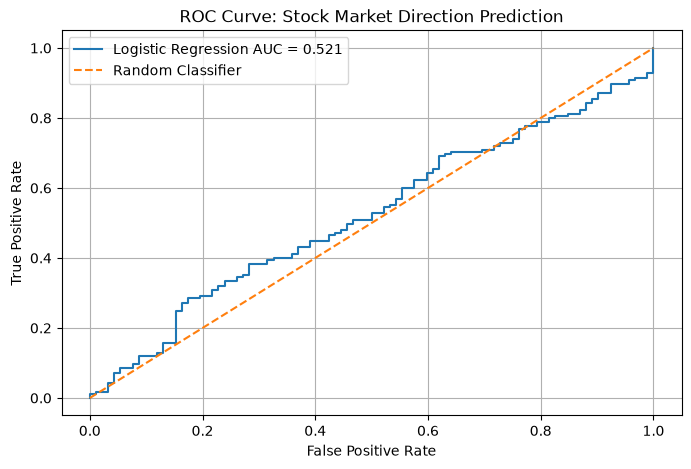

In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Stock Market Direction Prediction")
plt.legend()
plt.grid(True)

plt.show()

**Coefficient Table**

In [21]:
coefficient_table = pd.DataFrame({
    "Feature": features,
    "Coefficient": logit_model.named_steps["logistic"].coef_[0]
})

coefficient_table["Abs_Coefficient"] = coefficient_table["Coefficient"].abs()

coefficient_table = coefficient_table.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

coefficient_table

,Feature,Coefficient,Abs_Coefficient
2,HML_Lag1,-0.141016,0.141016
0,Mkt_RF_Lag1,-0.104536,0.104536
5,Rolling_12M_Volatility,-0.071535,0.071535
4,Recession_Lag1,-0.049234,0.049234
1,SMB_Lag1,-0.014610,0.014610
3,Yield_Spread_Lag1,-0.005300,0.005300


**Prediction Table**

In [22]:
predictions = test[
    [
        "Date",
        "Next_Month_Mkt_RF",
        "Market_Up_Next_Month"
    ]
].copy()

predictions["Predicted_Probability_Up"] = y_pred_prob
predictions["Predicted_Class"] = y_pred

predictions.head()

,Date,Next_Month_Mkt_RF,Market_Up_Next_Month,Predicted_Probability_Up,Predicted_Class
276,2005-01-01,1.88,1,0.640260,1
277,2005-02-01,-1.94,0,0.620937,1
278,2005-03-01,-2.61,0,0.634975,1
279,2005-04-01,3.65,1,0.661928,1
280,2005-05-01,0.58,1,0.626866,1


**Plot: Predicted Probability**

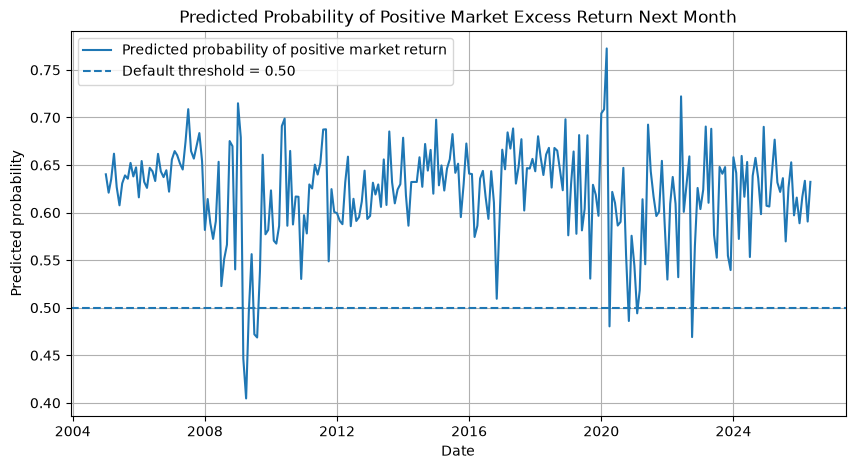

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(
    predictions["Date"],
    predictions["Predicted_Probability_Up"],
    label="Predicted probability of positive market return"
)

plt.axhline(0.50, linestyle="--", label="Default threshold = 0.50")

plt.xlabel("Date")
plt.ylabel("Predicted probability")
plt.title("Predicted Probability of Positive Market Excess Return Next Month")
plt.legend()
plt.grid(True)

plt.show()

**Benchmark**

In [24]:
always_up_accuracy = y_test.mean()

benchmark_results = pd.DataFrame({
    "Model": ["Always predict market up", "Logistic Regression"],
    "Accuracy": [always_up_accuracy, accuracy],
    "ROC-AUC": [np.nan, auc]
})

benchmark_results

,Model,Accuracy,ROC-AUC
0,Always predict market up,0.642023,NaN
1,Logistic Regression,0.607004,0.521344


## END